In [1]:
# !pip install textblob

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords , wordnet
from nltk import pos_tag
import re
import string
import warnings

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [5]:
# from textblob import TextBlob
# from textblob import Word

## Load Data

In [6]:
df = pd.read_csv('Mental-Health-Twitter.csv')
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


## ขั้นตอนที่ 2 Exploratory Data Analysis

In [7]:
df.info()
# 11 Column 
# 20K Row
# No missing data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    20000 non-null  int64 
 1   post_id       20000 non-null  int64 
 2   post_created  20000 non-null  object
 3   post_text     20000 non-null  object
 4   user_id       20000 non-null  int64 
 5   followers     20000 non-null  int64 
 6   friends       20000 non-null  int64 
 7   favourites    20000 non-null  int64 
 8   statuses      20000 non-null  int64 
 9   retweets      20000 non-null  int64 
 10  label         20000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 1.7+ MB


In [8]:
df.isnull().sum()
# Missing Values = 0

Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64

In [9]:
print(df['label'].value_counts())
# Balanced Target

label
1    10000
0    10000
Name: count, dtype: int64


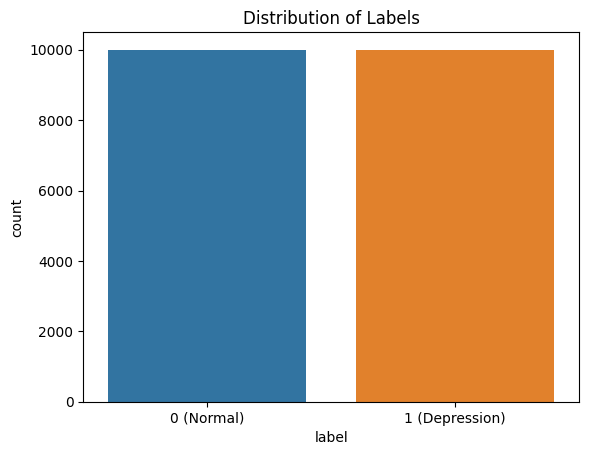

In [10]:
warnings.filterwarnings('ignore')

sns.countplot(x = 'label', data = df, palette = "tab10")
plt.title('Distribution of Labels')
plt.xticks(ticks = [0, 1], labels = ['0 (Normal)', '1 (Depression)'], rotation = 0)
plt.show()

## Data Preprocessing & Data Cleaning

In [11]:
lemmatizer = WordNetLemmatizer() #แปลงคำให้อยู่ในรูปพื้นฐาน เช่น organized => organize
stop_words = set(stopwords.words('english')) - {"no", "not", "don", "don't", "wasn't", "weren't", "isn't", "shouldn't", "wouldn't"} 
#stopwords => ลบคำทั่วๆไป แต่ไม่ค่อยสื่อความหมาย

# สร้าง Dictionary คำย่อ (อาจจะไม่ครบทุกคำ)
abbrev_map = {
    "idk": "i do not know","imo": "in my opinion","imho": "in my humble opinion","smh": "shaking my head","tbh": "to be honest",
    "btw": "by the way","omg": "oh my god","lol": "laughing out loud","lmao": "laughing my ass off","rofl": "rolling on the floor laughing",
    "brb": "be right back","bbl": "be back later","afaik": "as far as i know","fyi": "for your information","ikr": "i know right",
    "idc": "i do not care","kms": "kill myself","np": "no problem","nvm": "never mind","rn": "right now","ty": "thank you",
    "thx": "thanks","tysm": "thank you so much","yw": "you are welcome","bc": "because","bcz": "because","coz": "because",
    "cuz": "because","u": "you","ur": "your","urs": "yours","r": "are","ya": "you","plz": "please","pls": "please","thx": "thanks",
    "tho": "though","ttyl": "talk to you later","btw": "by the way","bcuz": "because","wanna": "want to","gonna": "going to",
    "gotta": "got to","kinda": "kind of","sorta": "sort of","lemme": "let me","gimme": "give me","ain't": "is not","ya'll": "you all",
    "yall": "you all","bruh": "bro","bro": "brother","omfg": "oh my fucking god","wtf": "what the fuck","wth": "what the hell","lmao": "laughing my ass off",
    "roflmao": "rolling on the floor laughing my ass off","ily": "i love you","ily2": "i love you too","oomf": "one of my friend","oomfs": "one of my friends",
    "ilyt": "i love you too","ilysm": "i love you so much","bff": "best friend forever","bf": "boyfriend","gf": "girlfriend","bae": "before anyone else",
    "oml": "oh my lord","ikr": "i know right","idc": "i do not care","imma": "i am going to","ima": "i am going to","gonna": "going to",
    "wanna": "want to","gotta": "have got to","tryna": "trying to","outta": "out of","lotta": "a lot of","kinda": "kind of",
    "sorta": "sort of","b4": "before","gr8": "great","l8r": "later","2day": "today","2moro": "tomorrow","2nite": "tonight","tmrw": "tomorrow",
    "24/7": "all the time","afk": "away from keyboard","irl": "in real life","dm": "direct message","pm": "private message","gg": "good game",
    "wp": "well played","ez": "easy","nsfw": "not safe for work","brb": "be right back","tmi": "too much information","fb": "facebook","ig": "instagram",
    "yt": "youtube","tt": "tiktok","op": "overpowered","nerf": "weaken","meta": "most effective tactic available","sus": "suspicious","fr": "for real",
    "rn": "right now","ngl": "not gonna lie","noob": "newbie","ggwp": "good game well played","asap": "as soon as possible","atm": "at the moment",
    "biz": "business","dept": "department","msg": "message","aka": "also known as","est": "established","info": "information","bc": "because",
    "faq": "frequently asked questions","lolz": "laughs","jk": "just kidding","np": "no problem","ok": "okay","okie": "okay","kk": "okay",
    "yea": "yeah","yeah": "yes","yup": "yes","nope": "no","naw": "no",
}

def expand_abbrev(text):
    return " ".join([abbrev_map.get(w, w) for w in text.split()])

# แปลง POS tag ของ nltk => รูปแบบที่ wordnet ใช้
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, 
                "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

In [12]:

def clean_text(text):
    text = text.lower() #แปลงเป็นตัวพิมพ์เล็กทั้งหมด
    text = re.sub(r'\brt\b', '', text) #ลบ RT
    text = re.sub(r'http\S+|www\S+', '', text) #ลบ URL
    text = re.sub(r'@\w+', '', text) #ลบ mentions (@username)
    text = re.sub(r'#', '', text) #ลบเครื่องหมาย hastag
    text = re.sub(r"[^\x00-\x7f]", " ", text) #ลบอักขระ non-ASCII(emoji or ภาษาอื่น)
    text = text.translate(str.maketrans('', '', string.punctuation)) #ลบเครื่องหมายวรรคตอน
    text = re.sub(r'[^a-z\s]', '', text) #ลบอักขระที่ไม่ใช่ตัวอักษร
    text = re.sub(r'(.)\1{2,}', r'\1', text) #ลดตัวอักษรซ้ำ
    text = re.sub(r'\s+', ' ', text).strip() #ลบช่องว่างซ้ำ และตัดช่องว่างหัวท้าย
    text = expand_abbrev(text) #ขยายคำย่อ
    tokens = nltk.word_tokenize(text) #Tokenization => แยกคำ
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1] #ลบ Stop Words และทำ Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    #รวมคำกลับเป็นประโยค
    return " ".join(cleaned_tokens)
    

In [13]:
df['cleaned_post_text'] = df['post_text'].apply(clean_text) 
print("Original Text:", df['post_text'].iloc[0])
print()
print("Cleaned Post Text:", df['cleaned_post_text'].iloc[0])

Original Text: It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.

Cleaned Post Text: year since diagnose anxiety depression today im take moment reflect far ive come since


## Feature Extraction / Vectorization

In [14]:
vectorizer = TfidfVectorizer(max_features=2000, min_df=5)

cleaned_post_text_tfidf = vectorizer.fit_transform(df['cleaned_post_text'])
feature_names_new_df = vectorizer.get_feature_names_out()

new_df = pd.DataFrame(cleaned_post_text_tfidf.toarray(), 
                        columns=[f"tfidf_{word}" for word in vectorizer.get_feature_names_out()])

df = pd.concat([df.reset_index(drop=True), new_df.reset_index(drop=True)], axis=1)
df = df.drop(columns=['cleaned_post_text'])
df = df.drop(columns=['post_text'])

In [15]:
df['post_created'] = pd.to_datetime(df['post_created'], format='%a %b %d %H:%M:%S %z %Y')

df['year'] = df['post_created'].dt.year
df['month'] = df['post_created'].dt.month
df['day'] = df['post_created'].dt.day
# df['minute'] = df['post_created'].dt.minute
# df['second'] = df['post_created'].dt.second
df['weekday'] = df['post_created'].dt.weekday
df['hour'] = df['post_created'].dt.hour

# สร้าง feature categorical 'time_of_day'
df['time_of_day'] = pd.cut(
    df['hour'],
    bins=[-1, 6, 12, 18, 24],
    labels=['night', 'morning', 'afternoon', 'evening']
)

le = LabelEncoder()
df['time_of_day'] = le.fit_transform(df['time_of_day'])

df = df.drop(columns=['post_created'])
df = df.drop(columns=['hour'])
df = df.drop(columns=['post_id'])
df = df.drop(columns=['user_id'])
df = df.drop(columns=['Unnamed: 0'])

In [16]:
print("New df shape:", new_df.shape)
print(new_df.head())

print("New df shape:", df.shape)
print(df.head())


New df shape: (20000, 2000)
   tfidf_ability  tfidf_able  tfidf_absolute  tfidf_absolutely  tfidf_abuse  \
0            0.0         0.0             0.0               0.0          0.0   
1            0.0         0.0             0.0               0.0          0.0   
2            0.0         0.0             0.0               0.0          0.0   
3            0.0         0.0             0.0               0.0          0.0   
4            0.0         0.0             0.0               0.0          0.0   

   tfidf_ac  tfidf_accept  tfidf_accident  tfidf_accidentally  \
0       0.0           0.0             0.0                 0.0   
1       0.0           0.0             0.0                 0.0   
2       0.0           0.0             0.0                 0.0   
3       0.0           0.0             0.0                 0.0   
4       0.0           0.0             0.0                 0.0   

   tfidf_accomplish  ...  tfidf_youre  tfidf_youth  tfidf_youtube  \
0               0.0  ...          0.0

## Feature Selection

In [17]:
X = new_df
y = df['label']
    
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

## Evaluate Model

### LogisticReg + new_df

In [18]:
X = new_df
y = df['label']
    
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report ,log_loss, confusion_matrix, f1_score

lasso_model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear')
lasso_model.fit(X_train, y_train)

coefficients = lasso_model.coef_[0] # ดึงค่าสัมประสิทธิ์

lasso_features = pd.DataFrame({
    'feature': feature_names_new_df,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

lasso_top_features = lasso_features[lasso_features['abs_coefficient'] > 0].sort_values(
    by='abs_coefficient', ascending=False
)

print("Top Features from Lasso")
print(lasso_top_features.head(10))

y_train_pred = lasso_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
    
y_test_pred = lasso_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

y_pred_proba =lasso_model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)
y_pred = lasso_model.predict(X_test)

print(f"Accuracy on Training Set: {train_accuracy:.4f}")
print(f"Accuracy on Testing Set:  {test_accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")
print()
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Top Features from Lasso
           feature  coefficient  abs_coefficient
1983          yong   -10.957099        10.957099
465     depression    10.315361        10.315361
1833         trump    -9.659545         9.659545
49           aleph    -7.453049         7.453049
1106      migraine     7.261935         7.261935
1908  wearepayting    -6.793926         6.793926
1124        mnwild     6.672746         6.672746
788       headache     6.648951         6.648951
916            joe    -6.624483         6.624483
1388         putin    -6.583993         6.583993
Accuracy on Training Set: 0.7874
Accuracy on Testing Set:  0.7308
Test Loss: 0.5031

              precision    recall  f1-score   support

           0       0.70      0.77      0.74      1948
           1       0.76      0.69      0.73      2052

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.73      0.73      0.73      4000

Confusion Matrix:
 [[1501

### LogisticReg + df

In [21]:
X = df.drop(columns=['label'])
feature_names_df = X.columns.tolist()
y = df['label']
    
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report ,log_loss, confusion_matrix, f1_score

lasso_model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear')
lasso_model.fit(X_train, y_train)

coefficients = lasso_model.coef_[0]

lasso_features = pd.DataFrame({
    'feature': feature_names_df,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

lasso_top_features = lasso_features[lasso_features['abs_coefficient'] > 0].sort_values(
    by='abs_coefficient', ascending=False
)

print("Top Features from Lasso")
print(lasso_top_features.head(10)) 

y_train_pred = lasso_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
    
y_test_pred = lasso_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

y_pred_proba =lasso_model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)
y_pred = lasso_model.predict(X_test)

print(f"Accuracy on Training Set: {train_accuracy:.4f}")
print(f"Accuracy on Testing Set:  {test_accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")
print()
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Top Features from Lasso
                        feature  coefficient  abs_coefficient
1988                 tfidf_yong   -43.798315        43.798315
1913         tfidf_wearepayting   -36.504672        36.504672
1989  tfidf_yongkissreturnonpbb   -25.715211        25.715211
1844             tfidf_tuesyong   -16.662110        16.662110
171                    tfidf_be   -16.457113        16.457113
1796           tfidf_tilltheend   -15.717740        15.717740
738                tfidf_gopayt   -15.203493        15.203493
516         tfidf_dreamteamyong   -15.086318        15.086318
1838                tfidf_trump   -14.522945        14.522945
470            tfidf_depression    12.275963        12.275963
Accuracy on Training Set: 0.9249
Accuracy on Testing Set:  0.9075
Test Loss: 0.2284

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1986
           1       0.89      0.93      0.91      2014

    accuracy                           0.91  

### ANOVA + MLP + new_df

In [23]:
X = new_df
y = df['label']
    
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [24]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report ,log_loss, confusion_matrix, f1_score

feature_names_new_df = X_train.columns.tolist()

k = 1000

anova_filter = SelectKBest(score_func=f_classif, k=k)
anova_filter.fit(X_train, y_train)

selected_indices = anova_filter.get_support(indices=True)
scores = anova_filter.scores_

valid = ~pd.isna(scores)
selected_indices = np.array(selected_indices)[valid[selected_indices]]

top_k_features = np.array(feature_names_new_df)[selected_indices]
scores = scores[selected_indices]

anova_top_features = pd.DataFrame({
    'feature': top_k_features,
    'f_score': scores
}).sort_values(by='f_score', ascending=False)

print(f"Top {min(30, k)} Features from ANOVA F-test")
print(anova_top_features.head(30))

X_train_sel = anova_filter.transform(X_train)
X_test_sel = anova_filter.transform(X_test)

clf = MLPClassifier(max_iter=500)
MLPClassifier(max_iter= 500,alpha=0.05,hidden_layer_sizes=(5,))
clf.fit(X_train_sel, y_train)

y_train_pred = clf.predict(X_train_sel)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = clf.predict(X_test_sel)
test_accuracy = accuracy_score(y_test, y_test_pred)

y_pred_proba = clf.predict_proba(X_test_sel)
loss = log_loss(y_test, y_pred_proba)

print(f"Evaluation Results for k={k}")
print(f"Accuracy on Training Set: {train_accuracy:.4f}")
print(f"Accuracy on Testing Set:  {test_accuracy:.4f}")
print(f"Test Log Loss: {loss:.4f}\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix on Test Set:\n", confusion_matrix(y_test, y_test_pred))

Top 30 Features from ANOVA F-test
                   feature     f_score
225       tfidf_depression  548.194110
908            tfidf_trump  272.777726
906        tfidf_treatment  218.728096
989             tfidf_yong  205.647606
610         tfidf_overcome  162.971715
324           tfidf_follow  128.190587
393            tfidf_hello  123.309974
686            tfidf_putin  111.632807
548         tfidf_migraine  111.352838
916          tfidf_twitter  106.843791
536           tfidf_mental   95.613408
384           tfidf_health   94.167604
96    tfidf_bestmusicvideo   87.085608
642       tfidf_pillowtalk   86.079790
382         tfidf_headache   85.895215
998             tfidf_zayn   85.474821
866            tfidf_thank   85.131876
422     tfidf_iheartawards   84.377964
22             tfidf_aleph   84.369070
449              tfidf_joe   83.748946
949     tfidf_wearepayting   79.280535
328          tfidf_foryong   78.485540
47           tfidf_anytime   76.058191
748              tfidf_say   6

### ANOVA + MLP + df

In [25]:
X = df.drop(columns=['label'])
feature_names_df = X.columns.tolist()
y = df['label']
    
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [26]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss

feature_names_df = X_train.columns.tolist()

k = 1000

anova_filter = SelectKBest(score_func=f_classif, k=k)
anova_filter.fit(X_train, y_train)

selected_indices = anova_filter.get_support(indices=True)
scores = anova_filter.scores_

valid = ~pd.isna(scores)
selected_indices = np.array(selected_indices)[valid[selected_indices]]

top_k_features = np.array(feature_names_df)[selected_indices]
scores = scores[selected_indices]

anova_top_features = pd.DataFrame({
    'feature': top_k_features,
    'f_score': scores
}).sort_values(by='f_score', ascending=False)

print(f"Top {min(30, k)} Features from ANOVA F-test")
print(anova_top_features.head(30))

X_train_sel = anova_filter.transform(X_train)
X_test_sel = anova_filter.transform(X_test)

clf = MLPClassifier(max_iter=500)
MLPClassifier(max_iter= 500,alpha=0.05,hidden_layer_sizes=(5,))
clf.fit(X_train_sel, y_train)

y_train_pred = clf.predict(X_train_sel)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = clf.predict(X_test_sel)
test_accuracy = accuracy_score(y_test, y_test_pred)

y_pred_proba = clf.predict_proba(X_test_sel)
loss = log_loss(y_test, y_pred_proba)

print(f"Evaluation Results for k={k}")
print(f"Accuracy on Training Set: {train_accuracy:.4f}")
print(f"Accuracy on Testing Set:  {test_accuracy:.4f}")
print(f"Test Log Loss: {loss:.4f}\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix on Test Set:\n", confusion_matrix(y_test, y_test_pred))

Top 30 Features from ANOVA F-test
                  feature       f_score
995                  year  13769.847802
1              favourites   1080.270728
2                statuses   1034.636898
237      tfidf_depression    576.751506
905           tfidf_trump    276.894649
902       tfidf_treatment    248.520267
0                 friends    240.180020
984            tfidf_yong    199.647668
997                   day    173.112849
626        tfidf_overcome    161.436540
341          tfidf_follow    119.547923
563        tfidf_migraine    114.501719
409           tfidf_hello    112.794921
914         tfidf_twitter    105.353190
701           tfidf_putin     98.918187
28            tfidf_aleph     94.513509
402          tfidf_health     92.823179
552          tfidf_mental     91.904265
993            tfidf_zayn     90.636586
98   tfidf_bestmusicvideo     89.402753
400        tfidf_headache     88.949895
657      tfidf_pillowtalk     88.256474
439    tfidf_iheartawards     87.557027
52    

### ANOVA + XGBoost + new_df

In [27]:
X = new_df
y = df['label']
    
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [28]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

feature_names_new_df = X_train.columns.tolist()

k = 1000

anova_filter = SelectKBest(score_func=f_classif, k=k)
anova_filter.fit(X_train, y_train)

scores = anova_filter.scores_
valid = ~pd.isna(scores)
selected_indices = np.where(valid)[0]
top_k_features = np.array(feature_names_new_df)[selected_indices]
scores = scores[selected_indices]

anova_top_features = pd.DataFrame({
    'feature': top_k_features,
    'f_score': scores
}).sort_values(by='f_score', ascending=False)

print("Top {min(30, k)} Features from ANOVA F-test")
print(anova_top_features.head(30))

X_train_sel = anova_filter.transform(X_train)
X_test_sel = anova_filter.transform(X_test)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=1,
    eval_metric=['logloss', 'error'],
)

xgb_model.fit(
    X_train_sel, y_train,
    eval_set=[(X_train_sel, y_train), (X_test_sel, y_test)],
    verbose=False
)

evals_result = xgb_model.evals_result()

y_train_pred = xgb_model.predict(X_train_sel)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = xgb_model.predict(X_test_sel)
test_accuracy = accuracy_score(y_test, y_test_pred)

y_pred_proba = xgb_model.predict_proba(X_test_sel)
loss = log_loss(y_test, y_pred_proba)

print("Evaluation Results for k={k} (XGBoost)")
print(f"Accuracy on Training Set: {train_accuracy:.4f}")
print(f"Accuracy on Testing Set:  {test_accuracy:.4f}")
print(f"Test Log Loss: {loss:.4f}\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix on Test Set:\n", confusion_matrix(y_test, y_test_pred))

Top {min(30, k)} Features from ANOVA F-test
                    feature     f_score
465        tfidf_depression  559.040631
1833            tfidf_trump  274.026138
1826        tfidf_treatment  222.544503
1983             tfidf_yong  202.574099
1242         tfidf_overcome  166.103700
668            tfidf_follow  114.343954
1106         tfidf_migraine  113.303239
803             tfidf_hello  111.661393
1847          tfidf_twitter  106.472495
1388            tfidf_putin  100.980167
1090           tfidf_mental   91.836832
788          tfidf_headache   91.250558
790            tfidf_health   90.720309
1997             tfidf_zayn   86.444479
49              tfidf_aleph   85.708266
1908     tfidf_wearepayting   84.853223
680           tfidf_foryong   84.078945
92            tfidf_anytime   81.726165
186    tfidf_bestmusicvideo   80.359496
1301       tfidf_pillowtalk   79.224914
863      tfidf_iheartawards   78.556946
916               tfidf_joe   76.178839
1761            tfidf_thank   74.178

### ANOVA + XGBoost + df

In [31]:
X = df.drop(columns=['label'])
feature_names_df = X.columns.tolist()
y = df['label']
    
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [33]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

feature_names_df = X_train.columns.tolist()

k = 1000

anova_filter = SelectKBest(score_func=f_classif, k=k)
anova_filter.fit(X_train, y_train)

scores = anova_filter.scores_
valid = ~pd.isna(scores)
selected_indices = np.where(valid)[0]
top_k_features = np.array(feature_names_df)[selected_indices]
scores = scores[selected_indices]

anova_top_features = pd.DataFrame({
    'feature': top_k_features,
    'f_score': scores
}).sort_values(by='f_score', ascending=False)

print("Top {min(30, k)} Features from ANOVA F-test")
print(anova_top_features.head(30))

X_train_sel = anova_filter.transform(X_train)
X_test_sel = anova_filter.transform(X_test)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=1,
    eval_metric=['logloss', 'error'],
)

xgb_model.fit(
    X_train_sel, y_train,
    eval_set=[(X_train_sel, y_train), (X_test_sel, y_test)],
    verbose=False
)

evals_result = xgb_model.evals_result()

y_train_pred = xgb_model.predict(X_train_sel)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = xgb_model.predict(X_test_sel)
test_accuracy = accuracy_score(y_test, y_test_pred)

y_pred_proba = xgb_model.predict_proba(X_test_sel)
loss = log_loss(y_test, y_pred_proba)

print("Evaluation Results for k={k} (XGBoost)")
print(f"Accuracy on Training Set: {train_accuracy:.4f}")
print(f"Accuracy on Testing Set:  {test_accuracy:.4f}")
print(f"Test Log Loss: {loss:.4f}\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix on Test Set:\n", confusion_matrix(y_test, y_test_pred))

Top {min(30, k)} Features from ANOVA F-test
                   feature       f_score
2005                  year  13807.210611
2               favourites   1132.976614
3                 statuses   1047.393470
470       tfidf_depression    578.957950
1838           tfidf_trump    268.864340
1                  friends    235.504398
1831       tfidf_treatment    231.273588
1988            tfidf_yong    206.225421
1247        tfidf_overcome    167.953936
2007                   day    166.631903
1111        tfidf_migraine    112.186937
673           tfidf_follow    108.070993
808            tfidf_hello    106.874122
1393           tfidf_putin     97.143604
1852         tfidf_twitter     96.466116
795           tfidf_health     92.692261
1095          tfidf_mental     90.007051
2002            tfidf_zayn     89.645585
1913    tfidf_wearepayting     89.636195
685          tfidf_foryong     88.843546
793         tfidf_headache     86.411834
54             tfidf_aleph     85.448714
1766         